In [1]:


import tensorflow as tf
import tensorflow_decision_forests as tfdf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# numpy and pandas for data manipulation

# File system manangement
import os

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')


# matplotlib and seaborn for plotting
import seaborn as sns


from sklearnex import patch_sklearn
patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()




2026-02-09 12:29:38.788711: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-09 12:29:38.811324: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-09 12:29:38.917720: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-09 12:29:38.917763: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-09 12:29:38.938427: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

ModuleNotFoundError: No module named 'sklearnex'

In [ ]:
import tensorflow as tf; print(tf.__version__)


2.15.0


In [ ]:
import tensorflow_decision_forests as tfdf; print(tfdf.__version__)

1.8.0


In [ ]:
print("TensorFlow v" + tf.__version__)
print("TensorFlow Decision Forests v" + tfdf.__version__)

TensorFlow v2.15.0
TensorFlow Decision Forests v1.8.0


<mark>TF-DF supports all feature types natively, and no preprocessing is required.</mark>

- TF-DF doesn't support boolean fields yet. So we need to convert those fields into int. To account for the missing values in the boolean fields, we will replace them with zero.
- In this notebook, we will replace null value entries with zero for numerical columns as well and only let TF-DF handle the missing values in categorical columns.
- <mark>Note: You can choose to let TF-DF handle missing values in numerical columns if need be.</mark>

In [2]:
df = pd.read_csv("../train.csv")
df = df.drop_duplicates()


X = df.drop(columns=['Transported'])
y = df['Transported']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)


y_train_int = y_train.astype(int)
y_test_int = y_test.astype(int)

KeyError: "['Transported'] not found in axis"

In [3]:
# List of columns to fill missing values
cols_to_fill = ['VIP', 'CryoSleep', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Fill missing values with 0 in both train and test
X_train[cols_to_fill] = X_train[cols_to_fill].fillna(0)
X_test[cols_to_fill]  = X_test[cols_to_fill].fillna(0)

# Check missing values in train
print("Missing values in X_train:")
print(X_train.isnull().sum().sort_values(ascending=False))

# Check missing values in test
print("\nMissing values in X_test:")
print(X_test.isnull().sum().sort_values(ascending=False))


NameError: name 'X_train' is not defined



We will also convert the boolean fields CryoSleep and VIP to int.


In [7]:
# Convert to integers
X_train['VIP'] = X_train['VIP'].astype(int)
X_train['CryoSleep'] = X_train['CryoSleep'].astype(int)

X_test['VIP'] = X_test['VIP'].astype(int)
X_test['CryoSleep'] = X_test['CryoSleep'].astype(int)



The value of column Cabin is a string with the format Deck/Cabin_num/Side. Here we will split the Cabin column and create 3 new columns Deck, Cabin_num and Side, since it will be easier to train the model on those individual data.

Run the following command to split the column Cabin into columns Deck, Cabin_num and Side


In [8]:
# Split the 'Cabin' column into three new columns
for df in [X_train, X_test]:
    df[['Deck', 'Cabin_num', 'Side']] = df['Cabin'].str.split('/', expand=True)
    df.drop('Cabin', axis=1, inplace=True)




There's one more step required before we can train the model. We need to convert the datatset from Pandas format (pd.DataFrame) into TensorFlow Datasets format (tf.data.Dataset).



In [20]:
import tensorflow_decision_forests as tfdf
import pandas as pd

# Suppose your label column is 'Transported'
label = 'Transported'

# Combine X_train + y_train
train_ds_pd = pd.concat([X_train, y_train], axis=1)
valid_ds_pd = pd.concat([X_test, y_test], axis=1)

# Convert to TFDF datasets
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_ds_pd, label=label)
valid_ds = tfdf.keras.pd_dataframe_to_tf_dataset(valid_ds_pd, label=label)

print(f"{len(train_ds_pd)} examples in training, {len(valid_ds_pd)} examples in validation.")


VersionError: Detected incompatible Protobuf Gencode/Runtime versions when loading yggdrasil_decision_forests/dataset/data_spec.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.

# Select a Model

There are several tree-based models for you to choose from.

- RandomForestModel
- GradientBoostedTreesModel
- CartModel
- DistributedGradientBoostedTreesModel

To start, we'll work with a Random Forest. This is the most well-known of the Decision Forest training algorithms.


In [10]:
tfdf.keras.get_all_models()

[tensorflow_decision_forests.keras.RandomForestModel,
 tensorflow_decision_forests.keras.GradientBoostedTreesModel,
 tensorflow_decision_forests.keras.CartModel,
 tensorflow_decision_forests.keras.DistributedGradientBoostedTreesModel]

# Configure the model
TensorFlow Decision Forests provides good defaults for you (e.g. the top ranking hyperparameters on our benchmarks, slightly modified to run in reasonable time). If you would like to configure the learning algorithm, you will find many options you can explore to get the highest possible accuracy.

You can select a template and/or set parameters as follows:
```python

rf = tfdf.keras.RandomForestModel(hyperparameter_template="benchmark_rank1")

```
https://www.tensorflow.org/decision_forests/api_docs/python/tfdf/keras/RandomForestModel


# Create a Random Forest
Today, we will use the defaults to create the Random Forest Model. By default the model is set to train for a classification task.


In [11]:
rf = tfdf.keras.RandomForestModel()
rf.compile(metrics=["accuracy"]) # Optional, you can use this to include a list of eval metrics

Use /tmp/tmp87e5hoqp as temporary training directory


We will train the model using a one-liner.

In [12]:
rf.fit(x=train_ds)

Reading training dataset...
Training dataset read in 0:00:02.283143. Found 6954 examples.
Training model...


[INFO 26-02-06 00:44:53.9004 CET kernel.cc:1233] Loading model from path /tmp/tmp87e5hoqp/model/ with prefix 3e7feabd0519468e


Model trained in 0:00:06.807302
Compiling model...


[INFO 26-02-06 00:44:54.2318 CET decision_forest.cc:660] Model loaded with 300 root(s), 232684 node(s), and 13 input feature(s).
[INFO 26-02-06 00:44:54.2318 CET abstract_model.cc:1344] Engine "RandomForestGeneric" built
[INFO 26-02-06 00:44:54.2318 CET kernel.cc:1061] Use fast generic engine


Model compiled.


# Visualize the model

In [13]:
tfdf.model_plotter.plot_model_in_colab(rf, tree_idx=0, max_depth=3)

### Evaluate the model on the Out of bag (OOB) data and the validation dataset



Reading training dataset...
Training dataset read in 0:00:00.044548. Found 6954 examples.
Training model...


[INFO 26-02-06 00:46:33.4533 CET kernel.cc:1233] Loading model from path /tmp/tmp87e5hoqp/model/ with prefix 3e7feabd0519468e


Model trained in 0:00:06.994164
Compiling model...


[INFO 26-02-06 00:46:33.7426 CET decision_forest.cc:660] Model loaded with 300 root(s), 232684 node(s), and 13 input feature(s).
[INFO 26-02-06 00:46:33.7426 CET abstract_model.cc:1344] Engine "RandomForestGeneric" built
[INFO 26-02-06 00:46:33.7426 CET kernel.cc:1061] Use fast generic engine


Model compiled.


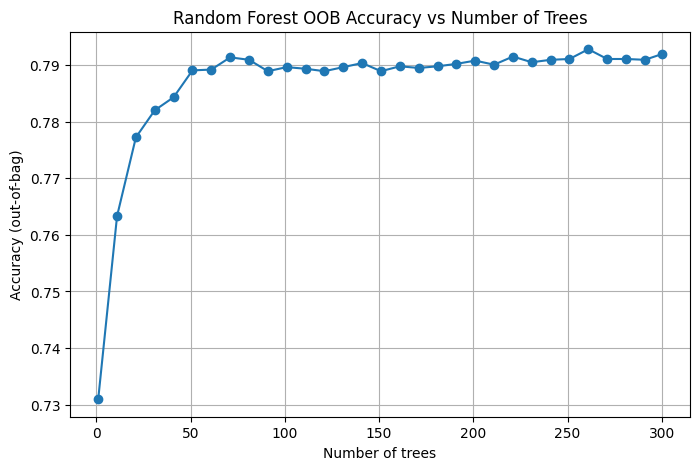

In [14]:
import matplotlib.pyplot as plt

# Make sure you already trained the model
rf.fit(train_ds)

# Get training logs (OOB accuracy per number of trees)
logs = rf.make_inspector().training_logs()

# Extract data
num_trees = [log.num_trees for log in logs]
accuracy = [log.evaluation.accuracy for log in logs]

# Plot
plt.figure(figsize=(8,5))
plt.plot(num_trees, accuracy, marker='o')
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.title("Random Forest OOB Accuracy vs Number of Trees")
plt.grid(True)
plt.show()




We can also see some general stats on the OOB dataset:


In [15]:
inspector = rf.make_inspector()
inspector.evaluation()

Evaluation(num_examples=6954, accuracy=0.7919183203911417, loss=0.5798081772098987, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)



Now, let us run an evaluation using the validation dataset.


In [16]:
evaluation = rf.evaluate(x=valid_ds,return_dict=True)

for name, value in evaluation.items():
  print(f"{name}: {value:.4f}")

2/2 [==============================] - 0s 61ms/step - loss: 0.0000e+00 - accuracy: 0.8039
loss: 0.0000
accuracy: 0.8039



### Variable importances


In [17]:


print(f"Available variable importances:")
for importance in inspector.variable_importances().keys():
  print("\t", importance)



Available variable importances:
	 INV_MEAN_MIN_DEPTH
	 SUM_SCORE
	 NUM_AS_ROOT
	 NUM_NODES


As an example, let us display the important features for the Variable Importance NUM_AS_ROOT.

The larger the importance score for NUM_AS_ROOT, the more impact it has on the outcome of the model.

In [18]:
# Each line is: (feature name, (index of the feature), importance score)
inspector.variable_importances()["NUM_AS_ROOT"]

[("CryoSleep" (1; #2), 103.0),
 ("RoomService" (1; #9), 62.0),
 ("Spa" (1; #12), 56.0),
 ("VRDeck" (1; #14), 32.0),
 ("ShoppingMall" (1; #10), 25.0),
 ("Deck" (4; #3), 11.0),
 ("FoodCourt" (1; #5), 7.0),
 ("HomePlanet" (4; #6), 4.0)]

# Submission

In [ ]:


# # Load the test dataset
# test_df = pd.read_csv('/kaggle/input/spaceship-titanic/test.csv')
# submission_id = test_df.PassengerId

# # Replace NaN values with zero
# test_df[['VIP', 'CryoSleep']] = test_df[['VIP', 'CryoSleep']].fillna(value=0)

# # Creating New Features - Deck, Cabin_num and Side from the column Cabin and remove Cabin
# test_df[["Deck", "Cabin_num", "Side"]] = test_df["Cabin"].str.split("/", expand=True)
# test_df = test_df.drop('Cabin', axis=1)

# # Convert boolean to 1's and 0's
# test_df['VIP'] = test_df['VIP'].astype(int)
# test_df['CryoSleep'] = test_df['CryoSleep'].astype(int)

# # Convert pd dataframe to tf dataset
# test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(test_df)

# # Get the predictions for testdata
# predictions = rf.predict(test_ds)
# n_predictions = (predictions > 0.5).astype(bool)
# output = pd.DataFrame({'PassengerId': submission_id,
#                        'Transported': n_predictions.squeeze()})

# output.head()







# sample_submission_df = pd.read_csv('/kaggle/input/spaceship-titanic/sample_submission.csv')
# sample_submission_df['Transported'] = n_predictions
# sample_submission_df.to_csv('/kaggle/working/submission.csv', index=False)
# sample_submission_df.head()



In [7]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

import os


# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import os
import sys
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src.config import Config as Config  
from src.data_loader import load_data, prepare_data

cfg = Config

KAGGLE_EVAL = cfg.KAGGLE_EVAL
RANDOM_STATE = cfg.RANDOM_STATE
TASK = cfg.TASK
USE_POSTPROCESSING = cfg.USE_POSTPROCESSING
TARGET = cfg.TARGET
ID = cfg.ID
SUB_PATH = cfg.SUB_PATH
SUBMIT_PROBABILITIES = cfg.SUBMIT_PROBABILITIES


from src.data_loader import load_data, prepare_data
# from src.optuna_utils import run_optuna
from src.evaluation_utils import evaluate_model, evaluate_metric
# from src.visualization_utils import plot_feature_importance, plot_learning_curve, shap_summary
from src.postprocessing_utils import optimize_postprocessing, apply_postprocessing
from src.data_splitter import DataSplitter
from src.experiment_tracker import ExperimentTracker
from sklearn.utils import compute_class_weight

# -------------------------------------------------------



sys.path contains: /home/ismail/x42


In [8]:
# -------------------------------
# Load & prepare data
# -------------------------------
X_train, X_test, y_train, y_test = load_data("encoded")
X_train, X_test, y_train_numeric, y_test_numeric, test_ids, num_classes, int_to_label = prepare_data(
    X_train, X_test, y_train, y_test, target=cfg.TARGET, drop_id=True
)

y_train_numeric = np.array(y_train_numeric)
y_test_numeric = np.array(y_test_numeric) if y_test_numeric is not None else None

# from sklearn.model_selection import train_test_split


# -------------------------------
# Data splitter
# -------------------------------
splitter = DataSplitter(
    method="stratified_kfold",
    n_splits=5,
    random_state=RANDOM_STATE,
    folds_path="data/folds.npy"
)
folds = list(splitter.split(X_train, y_train_numeric, reuse_folds=True, verbose=True))


Number of classes: 2
X_train shape: (300000, 116)
X_test shape: (200000, 116)
y_train shape: (300000,)
y_test labels are not available
✅ Loaded 5 folds from data/folds.npy
♻️ Reusing existing folds
--- Splitting data ---
Method: stratified_kfold
Number of splits: 5
Random seeds: [42]
Dataset size: 300000
Total folds: 5

Fold 0: Train size=12000, Val size=3000
Fold 1: Train size=12000, Val size=3000
Fold 2: Train size=12000, Val size=3000
Fold 3: Train size=12000, Val size=3000
Fold 4: Train size=12000, Val size=3000


In [25]:
import ydf
import pandas as pd
import numpy as np

# Final predictions storage
oof_preds = np.zeros((len(X_train), num_classes))
test_preds = np.zeros((len(X_test), num_classes))

# -------------------------------
# Training Loop
# -------------------------------
for fold_idx, (train_idx, val_idx) in enumerate(folds):
    print(f"\n--- Training YDF Fold {fold_idx + 1} ---")
    
    # Prepare data for this fold
    # YDF takes Pandas DataFrames directly
    train_df = X_train_df.iloc[train_idx].copy()
    train_df[TARGET] = y_train_numeric[train_idx]
    
    val_df = X_train_df.iloc[val_idx].copy()
    val_df[TARGET] = y_train_numeric[val_idx]
    
    # Initialize the Gradient Boosted Trees model
    # Equivalent to tfdf.keras.GradientBoostedTreesModel
    model = ydf.GradientBoostedTreesLearner(
        label=TARGET,
        task=ydf.Task.CLASSIFICATION,
        num_trees=500,
        max_depth=6,
        resume_training=False
    ).train(train_df)
    
    # OOF Predictions (returns probabilities)
    oof_preds[val_idx] = model.predict(val_df)
    
    # Test Predictions
    test_preds += model.predict(X_test_df) / len(folds)

# Final evaluation
overall_score = evaluate_metric(y_train_numeric, np.argmax(oof_preds, axis=1))
print(f"\nFinal YDF OOF Score: {overall_score}")

VersionError: Detected incompatible Protobuf Gencode/Runtime versions when loading yggdrasil_decision_forests/dataset/data_spec.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.

In [18]:
!pip install --no-deps --force-reinstall "protobuf>=6.31.1"

  Using cached protobuf-7.34.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
Using cached protobuf-7.34.1-cp310-abi3-manylinux2014_x86_64.whl (324 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.1
    Uninstalling protobuf-7.34.1:
      Successfully uninstalled protobuf-7.34.1


In [23]:
# Force a compatible Protobuf for the YDF/TF-DF ecosystem
!pip install --no-deps --force-reinstall "protobuf==5.29.1"
!pip install ydf --upgrade

  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.1
    Uninstalling protobuf-7.34.1:
      Successfully uninstalled protobuf-7.34.1
  Using cached ydf-0.16.1-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (3.8 kB)
  Using cached protobuf-7.34.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 4.6 MB/s  0:00:02 eta 0:00:01
Using cached protobuf-7.34.1-cp310-abi3-manylinux2014_x86_64.whl (324 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.1
    Uninstalling protobuf-5.29.1:
      Successfully uninstalled protobuf-5.29.1
  Attempting uninstall: ydf
    Found existing installation: ydf 0.16.0
    Uninstalling ydf-0.16.0:
      Successfully uninstalled ydf-0.16.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ydf]1/2 [ydf]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This beh